## APRENDIZADO SUPERVISIONADO

In [1]:
# Importando a classe LinearRegression para criar o modelo de regressão linear
from sklearn.linear_model import LinearRegression

# Importando a biblioteca NumPy para manipulação de arrays numéricos
import numpy as np

# ----------------------------
# 1. Criação dos dados simulados (contextualizados)
# ----------------------------
# Cenário: Queremos prever a venda de sorvetes com base na temperatura (em graus Celsius).
# 'temperaturas' será nossa variável independente (X), que influencia as vendas.
# Cada valor é colocado dentro de uma lista para formar uma matriz 2D, como o scikit-learn exige.
temperaturas = np.array([[20], [22], [24], [26], [28]])

# 'vendas' representa nossa variável dependente (Y), que é o número de sorvetes vendidos.
# Suponha que coletamos esses dados em dias diferentes.
vendas = np.array([200, 220, 245, 260, 280])

# ----------------------------
# 2. Criação do modelo de regressão linear
# ----------------------------
modelo = LinearRegression()

# ----------------------------
# 3. Treinamento (ajuste) do modelo
# ----------------------------
# Aqui, o modelo encontra a melhor linha que explica a relação entre temperatura e vendas.
modelo.fit(temperaturas, vendas)

# ----------------------------
# 4. Previsão com o modelo treinado
# ----------------------------
# Agora, vamos prever quantos sorvetes serão vendidos se a temperatura for 30°C.
# Novamente, passamos [[30]] no formato de matriz 2D.
venda_prevista = modelo.predict([[30]])

# ----------------------------
# 5. Exibição do resultado
# ----------------------------
# Exibimos a previsão formatada. Esse valor é baseado na tendência aprendida pelo modelo.
print(f"Previsão de vendas para 30°C: {venda_prevista[0]:.2f} sorvetes")

Previsão de vendas para 30°C: 301.00 sorvetes


## APRENDIZADO NÃO SUPERVISIONADO

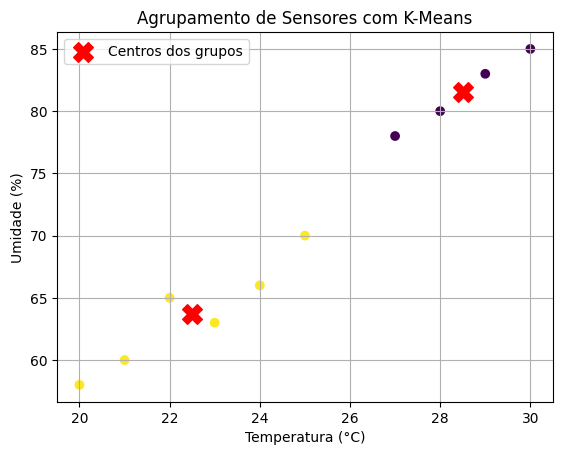

In [2]:
# Importando bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ----------------------------
# 1. Criação dos dados simulados (contextualizados)
# ----------------------------
# Cenário: Temos sensores em diferentes pontos da planta industrial
# medindo temperatura (°C) e umidade relativa do ar (%).
# Queremos descobrir, sem rótulos, quais sensores estão em condições semelhantes.
sensores = np.array([
    [22, 65], [23, 63], [24, 66], [28, 80], [27, 78],
    [30, 85], [21, 60], [20, 58], [29, 83], [25, 70]
])

# ----------------------------
# 2. Aplicação do algoritmo K-Means
# ----------------------------
# Definimos que queremos formar 2 grupos (clusters)
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(sensores)

# ----------------------------
# 3. Visualização dos agrupamentos
# ----------------------------
# Cada ponto será colorido conforme o grupo ao qual foi atribuído
plt.scatter(sensores[:, 0], sensores[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centros dos grupos')
plt.xlabel("Temperatura (°C)")
plt.ylabel("Umidade (%)")
plt.title("Agrupamento de Sensores com K-Means")
plt.legend()
plt.grid(True)
plt.show()

# Testando principais modelos do Machiner Learning

## ALGORITMOS SUPERVISIONADOS

## Regressão linear

In [3]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Dados simulados: horas de operação (X) e temperatura (y)
horas = np.array([100, 200, 300, 400, 500]).reshape(-1, 1)
temperatura = np.array([50, 55, 61, 66, 72])

# Criando o modelo de regressão linear
modelo = LinearRegression()

# Treinando o modelo com os dados
modelo.fit(horas, temperatura)

# Fazendo previsão para 600 horas de operação
prev_temp = modelo.predict([[600]])

print(f"Temperatura prevista: {prev_temp[0]:.2f} °C")

Temperatura prevista: 77.30 °C


## Regressão logística

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Dados simulados: vibração do motor (X) e falha (y: 0 = não, 1 = sim)
vibracao = np.array([[1.2],[2.5],[3.1],[4.8],[5.5]])
falha = np.array([0, 0, 0, 1, 1])

# Criando e treinando o modelo
modelo = LogisticRegression()
modelo.fit(vibracao, falha)

# Prevendo a probabilidade de falha para vibração = 4.0 mm/s
prob = modelo.predict_proba([[4.0]])[0][1]

print(f"Probabilidade de falha: {prob:.2f}")

Probabilidade de falha: 0.49


## KNN (K-Nearest Neighbors)

In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Dados simulados: nível de ruído (X) e status (0 = normal, 1 = crítico)
ruido = np.array([[30],[45],[50],[70],[80]])
status = np.array([0, 0, 1, 1, 1])

# Criando o modelo KNN com 3 vizinhos
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(ruido, status)

# Prevendo status para ruído = 55 dB
print("Status previsto:", modelo.predict([[55]])[0])

Status previsto: 1


## Árvores de decisão

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Dados simulados: pressão (bar) e status (0 = normal, 1 = crítico)
pressao = np.array([[2],[3],[4],[5],[6]])
status = np.array([0, 0, 1, 1, 1])

modelo = DecisionTreeClassifier()
modelo.fit(pressao, status)

# Prevendo status para 4.5 bar
print("Status previsto para 4.5 bar:", modelo.predict([[4.5]])[0])

Status previsto para 4.5 bar: 1


## Random forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(n_estimators=10)
modelo.fit(pressao, status)

print("Status previsto para 4.5 bar:", modelo.predict([[4.5]])[0])

Status previsto para 4.5 bar: 1


# Uso do XGBoost

In [11]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Carregando dataset Iris
dados = load_iris()
X = dados.data
y = dados.target

# Dividindo dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Criando modelo XGBoost
modelo = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
modelo.fit(X_train, y_train)

# Avaliando o modelo
acuracia = modelo.score(X_test, y_test)
print(f"Acurácia: {acuracia:.2f}")

Acurácia: 0.97


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:19:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## ALGORITMOS NÃO SUPERVISIONADOS

## K-Means

In [12]:
from sklearn.cluster import KMeans
import numpy as np

# Dados simulados: temperatura e vibração
dados = np.array([[50, 1.2],[55, 1.8],[60, 2.5],[80, 4.0],[85, 4.5]])

# Criando modelo KMeans com 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(dados)

print("Grupos atribuídos:", kmeans.labels_)

Grupos atribuídos: [0 0 0 1 1]


## PCA (Análise de Componentes Principais)

In [13]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Carregando dataset Iris
dados = load_iris()
X = dados.data

# Reduzindo para 2 componentes principais
pca = PCA(n_components=2)
X_reduzido = pca.fit_transform(X)

print("Dimensão original:", X.shape)
print("Após PCA:", X_reduzido.shape)

Dimensão original: (150, 4)
Após PCA: (150, 2)


#